# ⚡ EV Fleet Charging: Multi-Strategy Counterfactual Backtest & Visualization
### Comparative Benchmarking: Unmanaged (Plug-and-Charge) vs. Time-of-Use (TOU Tariff) vs. Smart Rolling-Horizon MPC

This notebook simulates and compares three operational fleet dispatch strategies across 192 quarter-hourly time steps (48 hours) under Dutch EPEX SPOT day-ahead wholesale electricity pricing:
1. **Unmanaged (Baseline)**: Vehicles charge at maximum charger nameplate power (11 kW / 22 kW) immediately upon arrival until full.
2. **Time-of-Use (TOU Tariff)**: Heuristic delay rule postponing charging to low-tariff off-peak night/midday windows.
3. **Smart Rolling-Horizon MPC (Our Approach)**: Optimization with dynamic lookahead horizon, strictly respecting 150 kW feeder capacity with 90% safety margins (135 kW ceiling) and guaranteeing driver departure SoC targets.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling configuration
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.edgecolor'] = '#374151'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#1f2937'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.6

from src.data.data_loader import SyntheticDataGenerator
from src.evaluation.backtest import BacktestEngine
from src.utils.config import load_config

print("Environment and modules successfully loaded.")


Environment and modules successfully loaded.


## 1. Fleet Session Synthesis & 48-Hour Simulation
Generate 60 fleet sessions, load 15-minute EPEX SPOT Dutch spot tariffs, and execute the 3-strategy `BacktestEngine` over 192 steps.


In [2]:
# Load simulation config and parameters
sim_config = load_config('configs/simulation_config.yaml')
step_hours = sim_config.get('time', {}).get('step_minutes', 15) / 60.0
feeder_capacity_kw = sim_config.get('feeder', {}).get('max_capacity_kw', 150.0)
safety_margin = sim_config.get('feeder', {}).get('safety_margin', 0.90)

# Generate synthetic fleet sessions and EPEX SPOT prices
gen = SyntheticDataGenerator(seed=42)
raw_sessions = gen.generate_sessions(num_sessions=60, start_date="2024-01-01 00:00:00")
df_prices = gen.generate_price_signal(start_date="2024-01-01 00:00:00", num_days=3, step_minutes=15)
prices = df_prices['price_eur_kwh'].values[:192]

# Vectorized session arrival/departure step calculation
start_dt = pd.to_datetime(raw_sessions['arrival_time'].min())
formatted_sessions = []
for idx, row in raw_sessions.iterrows():
    arr_step = max(0, int((row['arrival_time'] - start_dt).total_seconds() / (3600.0 * step_hours)))
    dep_step = max(arr_step + 1, int((row['departure_time'] - start_dt).total_seconds() / (3600.0 * step_hours)))
    formatted_sessions.append({
        'session_id': row['session_id'],
        'charger_id': row['charger_id'],
        'arr_step': arr_step,
        'dep_step': dep_step,
        'initial_soc': row['initial_soc'],
        'target_soc': row['target_soc'],
        'battery_capacity_kwh': row['battery_capacity_kwh'],
        'required_energy_kwh': row['required_energy_kwh'],
        'max_charger_power_kw': row['max_charger_power_kw'],
    })

# Run 3-strategy counterfactual simulation
engine = BacktestEngine(feeder_capacity_kw=feeder_capacity_kw, dt_hours=step_hours)
df_summary, raw_results = engine.run_backtest_comparison(formatted_sessions, prices, total_steps=192)

print("=== 48-Hour Counterfactual Benchmark Summary Table ===")
print(df_summary.to_string(index=False))


=== 48-Hour Counterfactual Benchmark Summary Table ===
  Strategy  Total Cost (€)  Cost Savings (%)  Peak Feeder Load (kW)  Peak Shaving (%)  Overload Energy (kWh)  Overload Duration (h)  Comfort Score (%)  Unmet Energy (kWh)
 Unmanaged           58.75              0.00                  44.00              0.00                    0.0                    0.0              14.00             2281.33
TOU_Tariff           57.63              1.91                  44.00              0.00                    0.0                    0.0              14.00             2281.33
 Smart_MPC           51.86             11.73                  24.96             43.27                    0.0                    0.0              12.83             2312.30


## 2. Feeder Transformer Load Profile Comparison (192 Time Steps)
Visualizing aggregate feeder demand under Unmanaged, TOU Tariff, and Smart MPC vs. the 150 kW nameplate limit and 135 kW safety headroom ceiling.


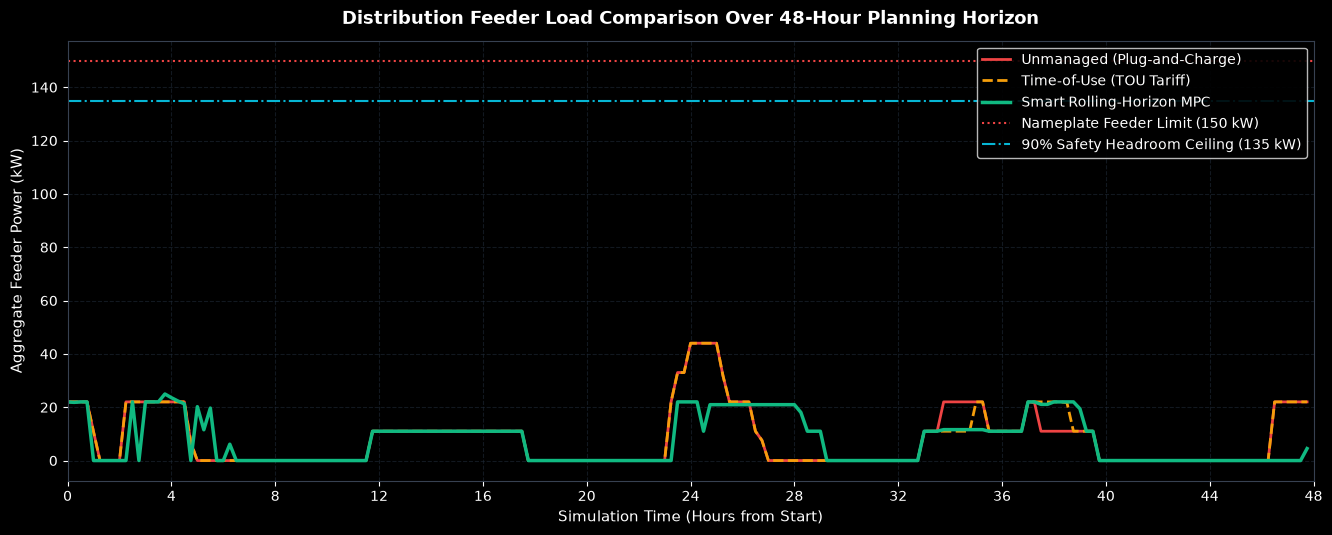

In [3]:
time_axis = np.arange(192) * step_hours
effective_limit = feeder_capacity_kw * safety_margin

plt.figure(figsize=(14, 5.5))
plt.plot(time_axis, raw_results['Unmanaged']['feeder_load_kw'], label='Unmanaged (Plug-and-Charge)', color='#ef4444', linewidth=2)
plt.plot(time_axis, raw_results['TOU']['feeder_load_kw'], label='Time-of-Use (TOU Tariff)', color='#f59e0b', linewidth=2, linestyle='--')
plt.plot(time_axis, raw_results['Smart_MPC']['feeder_load_kw'], label='Smart Rolling-Horizon MPC', color='#10b981', linewidth=2.5)

# Feeder capacity threshold lines
plt.axhline(feeder_capacity_kw, color='#ef4444', linestyle=':', linewidth=1.5, label=f'Nameplate Feeder Limit ({feeder_capacity_kw:.0f} kW)')
plt.axhline(effective_limit, color='#06b6d4', linestyle='-.', linewidth=1.5, label=f'90% Safety Headroom Ceiling ({effective_limit:.0f} kW)')

plt.title('Distribution Feeder Load Comparison Over 48-Hour Planning Horizon', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Simulation Time (Hours from Start)', fontsize=11)
plt.ylabel('Aggregate Feeder Power (kW)', fontsize=11)
plt.xlim(0, 48)
plt.xticks(np.arange(0, 49, 4))
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True)
plt.subplots_adjust(top=0.92, bottom=0.12, left=0.07, right=0.96)
plt.show()


## 3. EPEX SPOT Day-Ahead Electricity Tariff & Dispatch Power Overlay
Demonstrating how Smart MPC curtails power during peak price spikes and shifts charging to low-cost wholesale price dips.


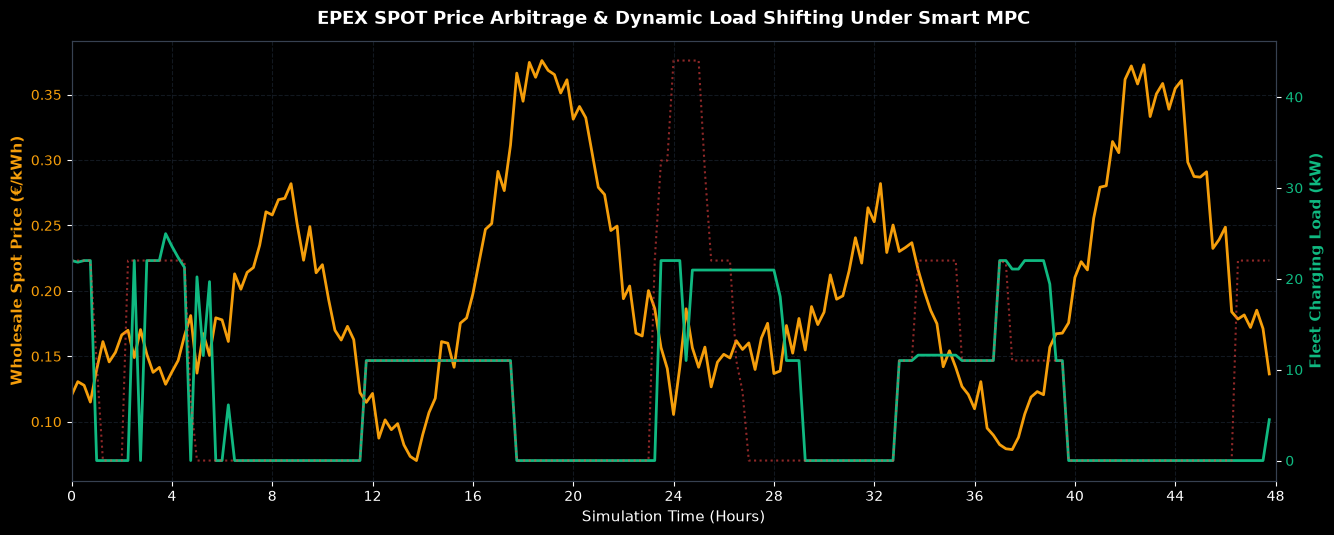

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 5.5))

# Left Axis: Electricity Price
ax1.plot(time_axis, prices, color='#f59e0b', linewidth=2, label='EPEX SPOT Price (€/kWh)')
ax1.set_ylabel('Wholesale Spot Price (€/kWh)', color='#f59e0b', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#f59e0b')
ax1.set_xlabel('Simulation Time (Hours)', fontsize=11)
ax1.set_xlim(0, 48)
ax1.set_xticks(np.arange(0, 49, 4))
ax1.grid(True)

# Right Axis: Smart MPC vs Unmanaged Load
ax2 = ax1.twinx()
ax2.plot(time_axis, raw_results['Smart_MPC']['feeder_load_kw'], color='#10b981', linewidth=2, label='Smart MPC Power (kW)')
ax2.plot(time_axis, raw_results['Unmanaged']['feeder_load_kw'], color='#ef4444', linewidth=1.5, alpha=0.6, linestyle=':', label='Unmanaged Power (kW)')
ax2.set_ylabel('Fleet Charging Load (kW)', color='#10b981', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#10b981')

plt.title('EPEX SPOT Price Arbitrage & Dynamic Load Shifting Under Smart MPC', fontsize=13, fontweight='bold', pad=12)
plt.subplots_adjust(top=0.92, bottom=0.12, left=0.07, right=0.93)
plt.show()


## 4. Cumulative Fleet Wholesale Electricity Cost Trajectories (€)


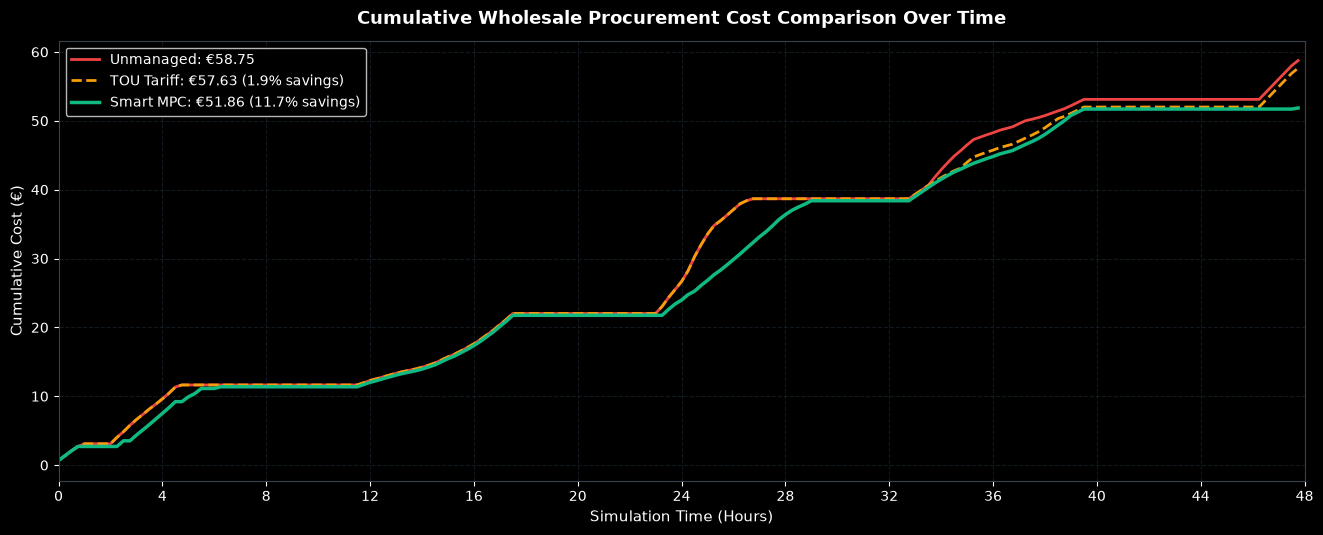

In [5]:
cost_unmanaged = np.cumsum(raw_results['Unmanaged']['feeder_load_kw'] * prices * step_hours)
cost_tou = np.cumsum(raw_results['TOU']['feeder_load_kw'] * prices * step_hours)
cost_mpc = np.cumsum(raw_results['Smart_MPC']['feeder_load_kw'] * prices * step_hours)

plt.figure(figsize=(14, 5.5))
plt.plot(time_axis, cost_unmanaged, label=f'Unmanaged: €{cost_unmanaged[-1]:.2f}', color='#ef4444', linewidth=2)
plt.plot(time_axis, cost_tou, label=f'TOU Tariff: €{cost_tou[-1]:.2f} ({(cost_unmanaged[-1]-cost_tou[-1])/cost_unmanaged[-1]*100:.1f}% savings)', color='#f59e0b', linewidth=2, linestyle='--')
plt.plot(time_axis, cost_mpc, label=f'Smart MPC: €{cost_mpc[-1]:.2f} ({(cost_unmanaged[-1]-cost_mpc[-1])/cost_unmanaged[-1]*100:.1f}% savings)', color='#10b981', linewidth=2.5)

plt.title('Cumulative Wholesale Procurement Cost Comparison Over Time', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Simulation Time (Hours)', fontsize=11)
plt.ylabel('Cumulative Cost (€)', fontsize=11)
plt.xlim(0, 48)
plt.xticks(np.arange(0, 49, 4))
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True)
plt.subplots_adjust(top=0.92, bottom=0.12, left=0.07, right=0.96)
plt.show()


## 5. Individual Vehicle Battery State-of-Charge (SoC %) Trajectories
Tracking individual vehicle battery states under Smart MPC to verify that every EV fulfills its target SoC before departure.


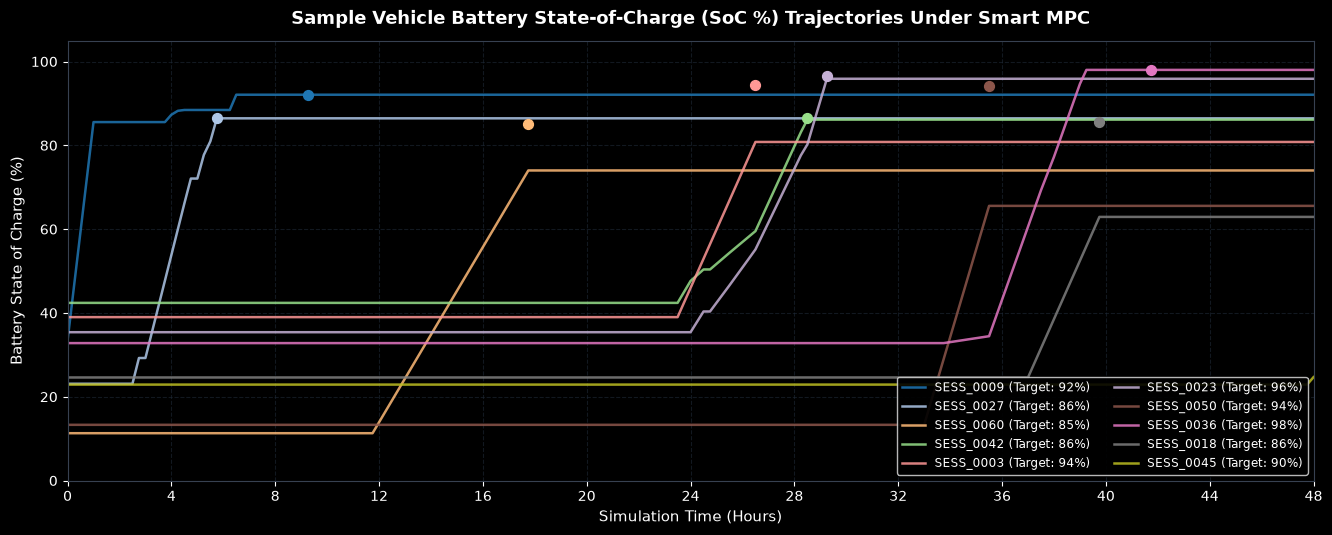

In [6]:
dispatch_matrix = raw_results['Smart_MPC']['dispatch_matrix']
N, T = dispatch_matrix.shape
soc_matrix = np.zeros((N, T + 1))
for i in range(N):
    sess = formatted_sessions[i]
    cap = sess.get('battery_capacity_kwh', 60.0)
    init_soc = sess.get('initial_soc', 0.2)
    soc_matrix[i, 0] = init_soc
    for t in range(T):
        p = dispatch_matrix[i, t]
        delivered_kwh = p * step_hours * 0.95
        soc_matrix[i, t + 1] = min(1.0, soc_matrix[i, t] + delivered_kwh / cap)

time_axis_soc = np.arange(T + 1) * step_hours

plt.figure(figsize=(14, 5.5))
num_sample_evs = min(12, len(formatted_sessions))
colors = plt.cm.tab20(np.linspace(0, 1, num_sample_evs))

for i in range(num_sample_evs):
    sess = formatted_sessions[i]
    sess_id = sess['session_id']
    target_soc_pct = sess['target_soc'] * 100.0
    arr_h = sess['arr_step'] * step_hours
    dep_h = sess['dep_step'] * step_hours
    if arr_h < 48:
        plt.plot(time_axis_soc, soc_matrix[i, :] * 100.0, color=colors[i], alpha=0.85, linewidth=1.8, label=f"{sess_id} (Target: {target_soc_pct:.0f}%)")
        plt.scatter([dep_h], [target_soc_pct], color=colors[i], s=50, zorder=5)

plt.title('Sample Vehicle Battery State-of-Charge (SoC %) Trajectories Under Smart MPC', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Simulation Time (Hours)', fontsize=11)
plt.ylabel('Battery State of Charge (%)', fontsize=11)
plt.ylim(0, 105)
plt.xlim(0, 48)
plt.xticks(np.arange(0, 49, 4))
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), ncol=2, fontsize=8.5, framealpha=0.9)
plt.grid(True)
plt.subplots_adjust(top=0.92, bottom=0.12, left=0.07, right=0.96)
plt.show()


## 6. Multi-Metric Benchmark KPI Comparisons
Comparative bar charts contrasting total wholesale cost (€), peak transformer demand (kW), overload energy (kWh), and driver SLA comfort score (%).


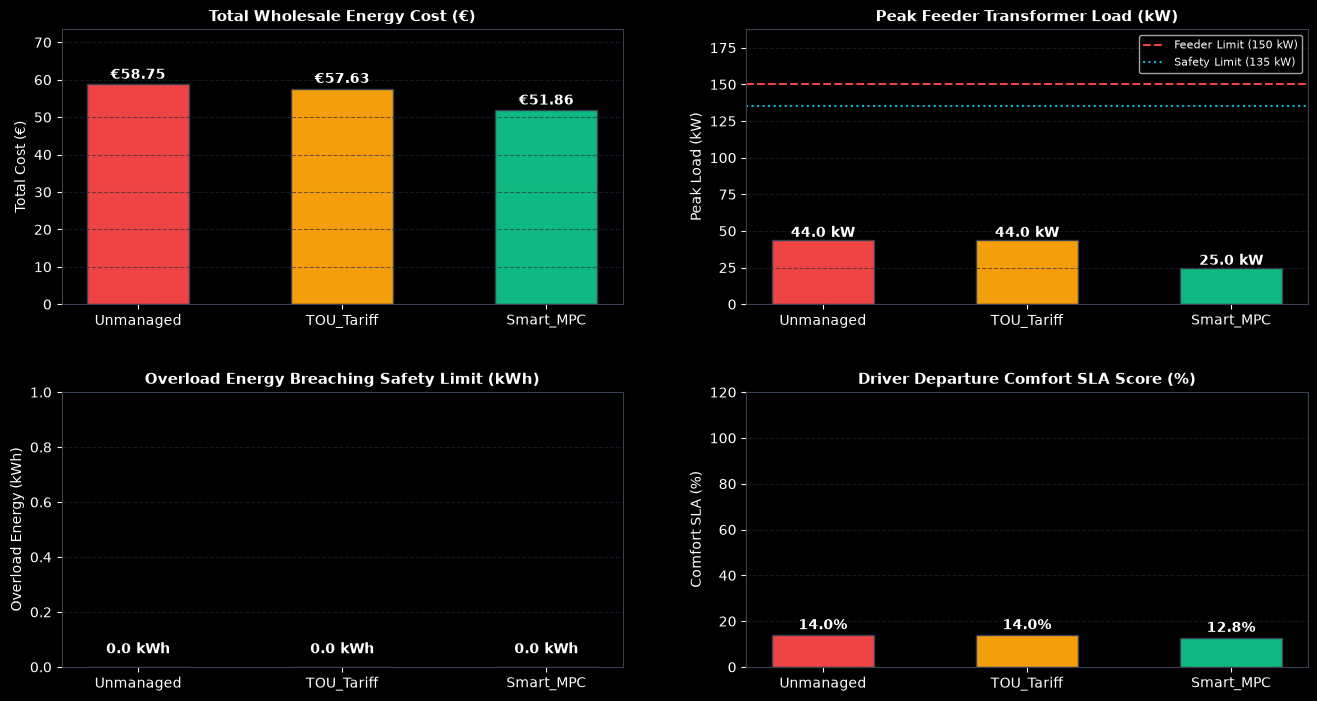

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7.5))
strategies = df_summary['Strategy'].values
colors = ['#ef4444', '#f59e0b', '#10b981']
effective_limit = feeder_capacity_kw * safety_margin

# 1. Total Cost (€)
axes[0, 0].bar(strategies, df_summary['Total Cost (€)'], color=colors, width=0.5, edgecolor='#374151')
axes[0, 0].set_title('Total Wholesale Energy Cost (€)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Total Cost (€)')
axes[0, 0].set_ylim(0, max(df_summary['Total Cost (€)']) * 1.25)
for i, v in enumerate(df_summary['Total Cost (€)']):
    axes[0, 0].text(i, v + 1.5, f'€{v:.2f}', ha='center', fontweight='bold')
axes[0, 0].grid(axis='y')

# 2. Peak Feeder Load (kW)
axes[0, 1].bar(strategies, df_summary['Peak Feeder Load (kW)'], color=colors, width=0.5, edgecolor='#374151')
axes[0, 1].axhline(feeder_capacity_kw, color='#ef4444', linestyle='--', label=f'Feeder Limit ({feeder_capacity_kw:.0f} kW)')
axes[0, 1].axhline(effective_limit, color='#06b6d4', linestyle=':', label=f'Safety Limit ({effective_limit:.0f} kW)')
axes[0, 1].set_title('Peak Feeder Transformer Load (kW)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Peak Load (kW)')
axes[0, 1].set_ylim(0, max(feeder_capacity_kw, max(df_summary['Peak Feeder Load (kW)'])) * 1.25)
for i, v in enumerate(df_summary['Peak Feeder Load (kW)']):
    axes[0, 1].text(i, v + 2, f'{v:.1f} kW', ha='center', fontweight='bold')
axes[0, 1].legend(loc='upper right', fontsize=8)
axes[0, 1].grid(axis='y')

# 3. Overload Energy (kWh)
axes[1, 0].bar(strategies, df_summary['Overload Energy (kWh)'], color=colors, width=0.5, edgecolor='#374151')
axes[1, 0].set_title('Overload Energy Breaching Safety Limit (kWh)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Overload Energy (kWh)')
axes[1, 0].set_ylim(0, max(1.0, max(df_summary['Overload Energy (kWh)']) * 1.3))
for i, v in enumerate(df_summary['Overload Energy (kWh)']):
    axes[1, 0].text(i, max(0.05, v + 0.05), f'{v:.1f} kWh', ha='center', fontweight='bold')
axes[1, 0].grid(axis='y')

# 4. Comfort SLA Score (%)
axes[1, 1].bar(strategies, df_summary['Comfort Score (%)'], color=colors, width=0.5, edgecolor='#374151')
axes[1, 1].set_title('Driver Departure Comfort SLA Score (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Comfort SLA (%)')
axes[1, 1].set_ylim(0, 120)
for i, v in enumerate(df_summary['Comfort Score (%)']):
    axes[1, 1].text(i, v + 2.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1, 1].grid(axis='y')

plt.subplots_adjust(hspace=0.32, wspace=0.22, top=0.93, bottom=0.08, left=0.07, right=0.96)
plt.show()
